In [23]:
import pandas as pd

In [24]:
# Read data from CSV file
df = pd.read_csv('artificial_1h_data.csv')

# Remove rows where Steps are zero
# df = df[df['Steps'] != 0]

# Convert 'Timestamp' to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Sort the DataFrame by Timestamp
df = df.sort_values(by='Timestamp')

In [25]:
df

,Timestamp,Steps,PAM Score
0,2025-05-01 12:00:00,4,0.31
1,2025-05-01 12:01:00,1,0.35
2,2025-05-01 12:02:00,3,0.27
3,2025-05-01 12:03:00,2,0.25
4,2025-05-01 12:04:00,1,0.25
5,2025-05-01 12:05:00,2,0.23
6,2025-05-01 12:06:00,2,0.24
7,2025-05-01 12:07:00,0,0.32
8,2025-05-01 12:08:00,4,0.27
9,2025-05-01 12:09:00,0,0.39


In [26]:
print(df)

             Timestamp  Steps  PAM Score
0  2025-05-01 12:00:00      4       0.31
1  2025-05-01 12:01:00      1       0.35
2  2025-05-01 12:02:00      3       0.27
3  2025-05-01 12:03:00      2       0.25
4  2025-05-01 12:04:00      1       0.25
5  2025-05-01 12:05:00      2       0.23
6  2025-05-01 12:06:00      2       0.24
7  2025-05-01 12:07:00      0       0.32
8  2025-05-01 12:08:00      4       0.27
9  2025-05-01 12:09:00      0       0.39
10 2025-05-01 12:10:00     20       0.48
11 2025-05-01 12:11:00     22       0.54
12 2025-05-01 12:12:00     20       0.52
13 2025-05-01 12:13:00     28       0.59
14 2025-05-01 12:14:00     15       0.40
15 2025-05-01 12:15:00     17       0.34
16 2025-05-01 12:16:00     18       0.39
17 2025-05-01 12:17:00     24       0.51
18 2025-05-01 12:18:00     15       0.56
19 2025-05-01 12:19:00     23       0.59
20 2025-05-01 12:20:00     12       0.35
21 2025-05-01 12:21:00     11       0.61
22 2025-05-01 12:22:00     18       0.58
23 2025-05-01 12

In [27]:
# Calculate average PAM score per step
total_steps = df['Steps'].sum()
total_pam_score = df['PAM Score'].sum()

# Avoid division by zero
if total_steps > 0:
    avg_pam_per_step = total_pam_score / total_steps
    print(f"Average PAM Score per Step: {avg_pam_per_step:.4f}")
else:
    print("No steps recorded — cannot compute average PAM Score per Step.")


Average PAM Score per Step: 0.0211


### Visualize the data

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns


class DataVisualizer:
    def __init__(self, data):
        self.data = data

    def plot_pam_score_over_time(self):
        sns.set(style="whitegrid")
        plt.figure(figsize=(12, 6))
        sns.lineplot(x=self.data['Timestamp'],
                     y=self.data['PAM Score'], marker='o')
        plt.title('PAM Score Over Time')
        plt.xlabel('Timestamp')
        plt.ylabel('PAM Score')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def plot_steps_over_time(self):
        sns.set(style="whitegrid")
        plt.figure(figsize=(12, 6))
        sns.lineplot(x=self.data['Timestamp'],
                     y=self.data['Steps'], marker='s', color='orange')
        plt.title('Steps Over Time')
        plt.xlabel('Timestamp')
        plt.ylabel('Steps')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def plot_dual_axis(self):
        fig, ax1 = plt.subplots(figsize=(12, 6))
        ax2 = ax1.twinx()
        ax1.plot(self.data['Timestamp'],
                 self.data['Steps'], 'g-', label='Steps')
        ax2.plot(self.data['Timestamp'],
                 self.data['PAM Score'], 'b-', label='PAM Score')

        ax1.set_xlabel('Timestamp')
        ax1.set_ylabel('Steps', color='g')
        ax2.set_ylabel('PAM Score', color='b')
        ax1.tick_params(axis='x', rotation=45)
        plt.title('Steps and PAM Score Over Time')
        fig.tight_layout()
        plt.show()


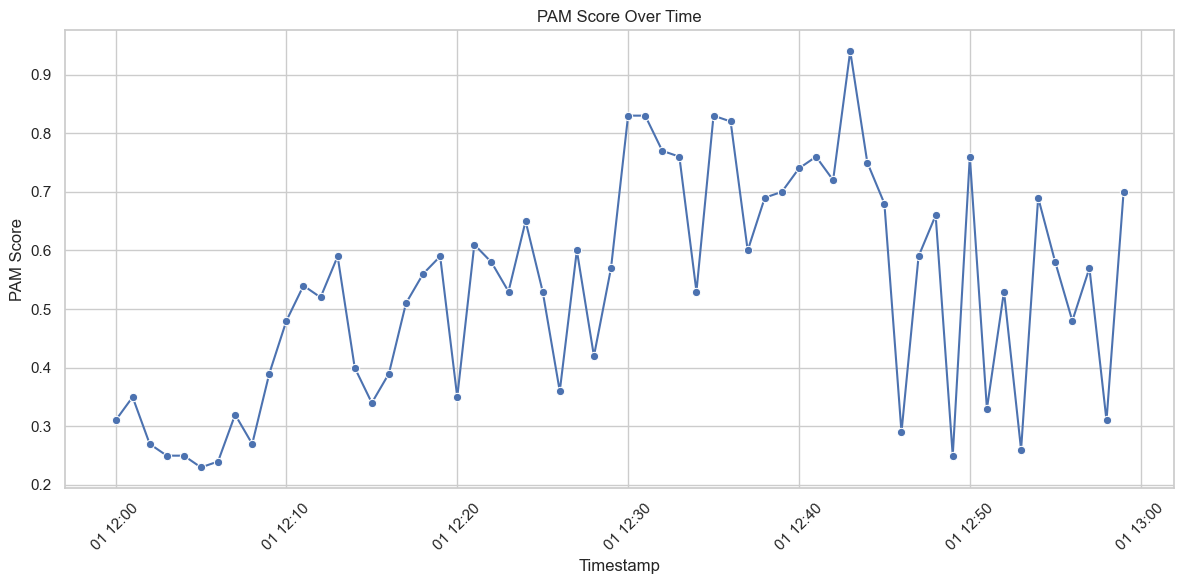

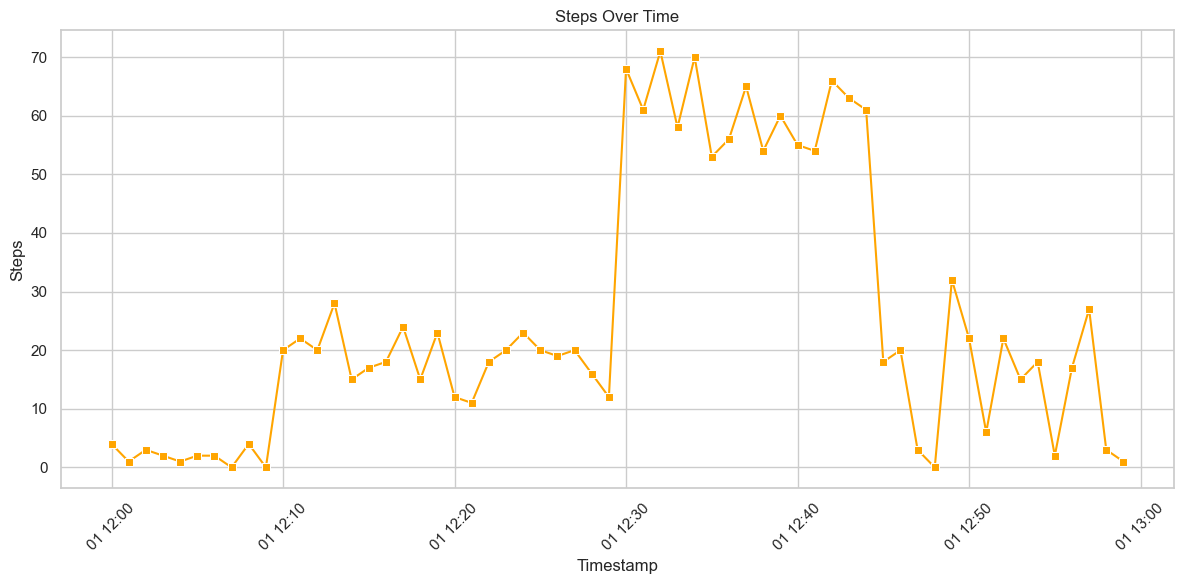

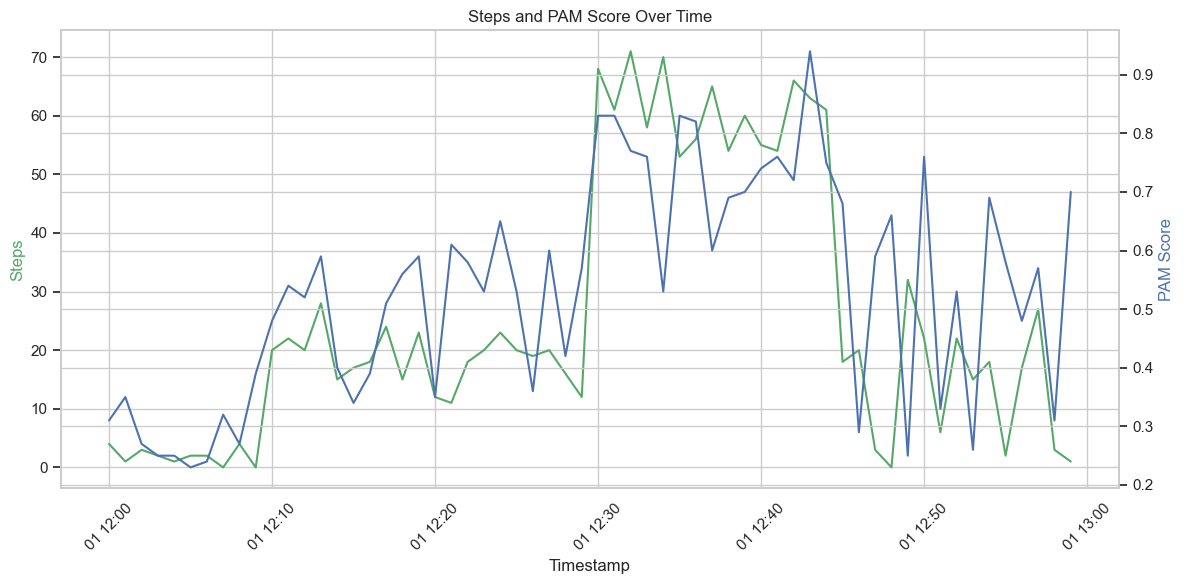

In [29]:
visualizer = DataVisualizer(df)
visualizer.plot_pam_score_over_time()
visualizer.plot_steps_over_time()
visualizer.plot_dual_axis()